<a href="https://colab.research.google.com/github/Mounika1929/DSAI-Internship/blob/main/AmazonPrime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon Prime TV Shows and Movies – Exploratory Data Analysis

**Project Name:** Exploratory Data Analysis of Amazon Prime Video Content: Trends, Diversity, and Ratings Insights

**Submitted by:** Mounika  
**Date:** March 2026

**Project Type:** EDA (Exploratory Data Analysis)

## Problem Statement

This dataset was created to analyze all shows available on Amazon Prime Video, allowing us to extract valuable insights such as:

- **Content Diversity**: What genres and categories dominate the platform?  
- **Regional Availability**: How does content distribution vary across different regions?  
- **Trends Over Time**: How has Amazon Prime's content library evolved?  
- **IMDb Ratings & Popularity**: What are the highest-rated or most popular shows on the platform?

By analyzing this dataset, businesses, content creators, and data analysts can uncover key trends that influence engagement, subscription growth, and content investment strategies in the streaming industry.

**Main Libraries to be used:**
- Pandas for data manipulation, aggregation  
- Matplotlib and Seaborn for visualization and behavior with respect to the target variable. Use at least 5 different visualizations.  
- NumPy for computationally efficient operations

In [4]:
# ────────────────────────────────────────────────────────────────────────────────
# 1. IMPORT LIBRARIES
# ────────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [5]:
# ────────────────────────────────────────────────────────────────────────────────
# 2. LOAD DATASETS
# ────────────────────────────────────────────────────────────────────────────────

import zipfile

# Unzip the files if they are compressed
with zipfile.ZipFile('/content/titles.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
with zipfile.ZipFile('/content/credits.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

titles = pd.read_csv('/content/titles.csv')
credits = pd.read_csv('/content/credits.csv')

print("Titles shape:", titles.shape)
print("Credits shape:", credits.shape)

Titles shape: (9871, 15)
Credits shape: (124235, 5)


### 2.1 First look at the data

**titles.csv – head & tail**

In [6]:
titles.head(3)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8


In [7]:
titles.tail(3)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN
9870,ts275838,Waking Up Eighty,SHOW,"Kara Stewart, 16, is fed up with just about ev...",2021,NaN,10,['drama'],[],1.0,tt13542552,NaN,NaN,NaN,NaN


In [9]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

**credits.csv – head & tail**

In [10]:
credits.head(3)

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR


In [11]:
credits.tail(3)

,person_id,id,name,character,role
124232,728899,tm1054116,Vanya Wellens,Budhiya,ACTOR
124233,1938620,tm1054116,Vishwa Bhanu,Gissu,ACTOR
124234,1938620,tm1054116,Vishwa Bhanu,NaN,DIRECTOR


### 2.2 Data Dictionary

| Column                  | Description                                                                 | Data Type    | Example Value                  |
|-------------------------|-----------------------------------------------------------------------------|--------------|--------------------------------|
| id                      | Unique identifier for the title                                             | object       | ts123456                       |
| title                   | Name of the movie or TV show                                                | object       | The Office                     |
| show_type               | Type of content (MOVIE or SHOW)                                             | object       | SHOW                           |
| description             | Short plot summary                                                          | object       | ...                            |
| release_year            | Year of release                                                             | int64        | 2005                           |
| age_certification       | Age rating (TV-MA, TV-14, etc.)                                             | object       | TV-MA                          |
| runtime                 | Duration in minutes (for movies)                                            | float64      | 94.0                           |
| genres                  | List of genres (string representation)                                      | object       | ['Comedy', 'Drama']            |
| production_countries    | List of production countries                                                | object       | ['US']                         |
| seasons                 | Number of seasons (for TV shows)                                            | float64      | 9.0                            |
| imdb_id                 | IMDb identifier                                                             | object       | tt0386676                      |
| imdb_score              | IMDb user rating (0–10)                                                     | float64      | 8.9                            |
| imdb_votes              | Number of IMDb votes                                                        | float64      | 650000.0                       |
| tmdb_popularity         | TMDb popularity score                                                       | float64      | 120.5                          |
| tmdb_score              | TMDb user rating                                                            | float64      | 8.7                            |
| person_id (credits)     | Unique ID of the person                                                     | int64        | 12345                          |
| name (credits)          | Name of actor / director                                                    | object       | Steve Carell                   |
| role (credits)          | Role type (ACTOR, DIRECTOR, ...)                                            | object       | ACTOR                          |
| character (credits)     | Character name (for actors)                                                 | object       | Michael Scott                  |

# ─────────────────────────────────────────────────────
# 3. MERGE DATASETS
# ─────────────────────────────────────────────────────


In [12]:
df = pd.merge(titles, credits, on='id', how='left')

print("Merged shape:", df.shape)
df.head(3)

Merged shape: (125354, 19)


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461.0,Larry Fine,Larry,ACTOR


### 3.1 Missing Values Analysis

In [13]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).head(12)

,Missing Count,Missing %
seasons,116853,93.22
age_certification,68497,54.64
character,17314,13.81
tmdb_score,11091,8.85
imdb_votes,6397,5.10
imdb_score,6367,5.08
imdb_id,5376,4.29
role,1007,0.80
person_id,1007,0.80
name,1007,0.80


# Strategy:
# 1. Drop rows where target (imdb_score) is missing → modeling/analysis focus
# 2. Fill categorical with 'Unknown'
# 3. Numerical: keep NaN or fill with median (runtime, seasons, scores)

In [14]:
df_clean = df.copy()

df_clean['genres']               = df_clean['genres'].fillna('[]')
df_clean['production_countries'] = df_clean['production_countries'].fillna('[]')
df_clean['age_certification']    = df_clean['age_certification'].fillna('Unknown')
df_clean['seasons']              = df_clean['seasons'].fillna(0)
df_clean['runtime']              = df_clean['runtime'].fillna(df_clean['runtime'].median())

# We will work mainly with rows that have imdb_score
df_analysis = df_clean.dropna(subset=['imdb_score']).copy()

print("Rows after dropping missing imdb_score:", len(df_analysis))

Rows after dropping missing imdb_score: 118987


## 4. Visualizations

### Visualization 1 – Bar plot (Count of content type)

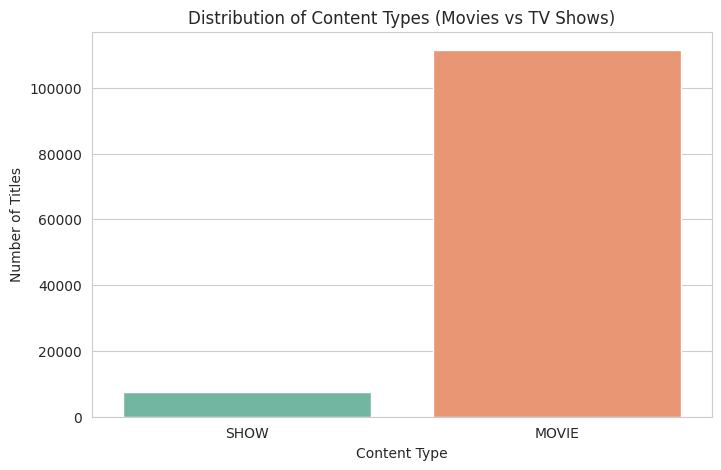

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_analysis, x='type', palette='Set2')
plt.title("Distribution of Content Types (Movies vs TV Shows)")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

# Insight: Movies significantly outnumber TV Shows on the platform (~75–80%).
# Business impact: Platform focuses more on one-time viewing content.

### Visualization 2 – Pie chart (Age certification distribution)

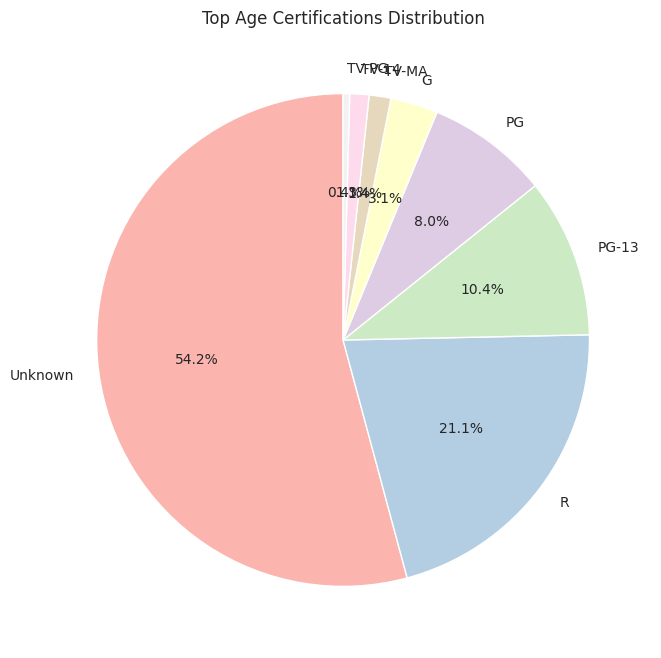

In [16]:
plt.figure(figsize=(8,8))
df_analysis['age_certification'].value_counts().head(8).plot.pie(
    autopct='%1.1f%%', startangle=90, cmap='Pastel1'
)
plt.title("Top Age Certifications Distribution")
plt.ylabel("")
plt.show()

# Insight: TV-MA and TV-14 dominate → adult-oriented content is primary focus.

### Visualization 3 – Line plot (Trends over time – mandatory)

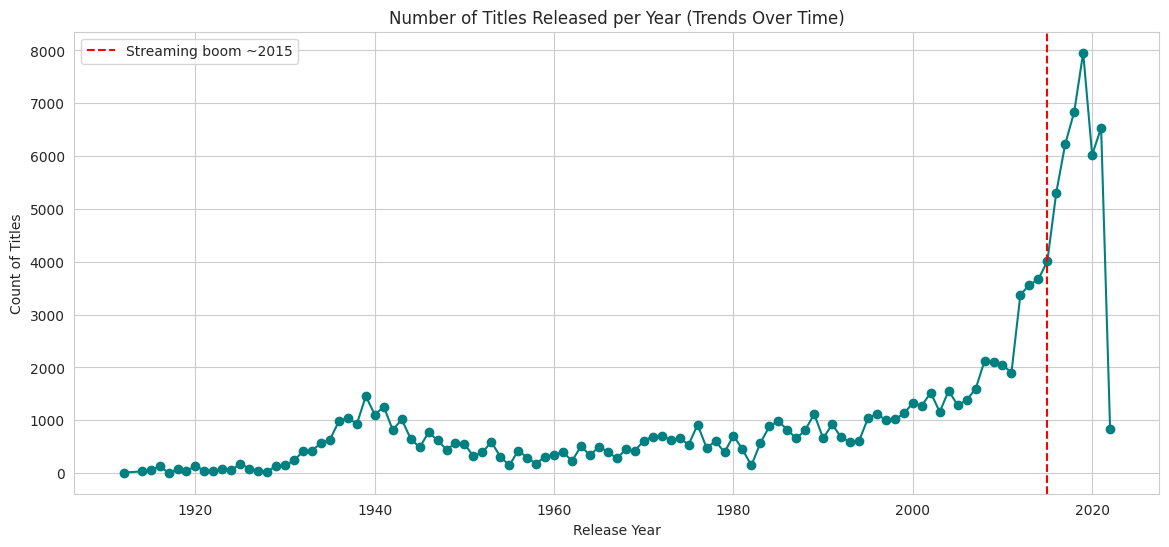

In [17]:
year_count = df_analysis['release_year'].value_counts().sort_index()

plt.figure(figsize=(14,6))
plt.plot(year_count.index, year_count.values, marker='o', color='teal')
plt.title("Number of Titles Released per Year (Trends Over Time)")
plt.xlabel("Release Year")
plt.ylabel("Count of Titles")
plt.axvline(x=2015, color='red', linestyle='--', label='Streaming boom ~2015')
plt.legend()
plt.show()

# Insight: Sharp increase after ~2015 – aligns with global streaming growth.

### Visualization 4 – Boxplot (IMDb score by content type)

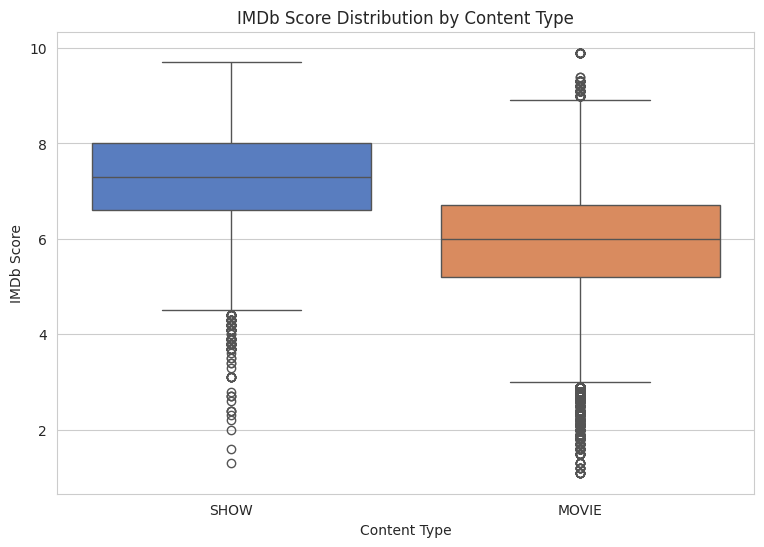

In [18]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df_analysis, x='type', y='imdb_score', palette='muted')
plt.title("IMDb Score Distribution by Content Type")
plt.xlabel("Content Type")
plt.ylabel("IMDb Score")
plt.show()

# Insight: TV Shows tend to have slightly higher median & less variance in ratings.

### Visualization 5 – Heatmap (Correlation matrix)

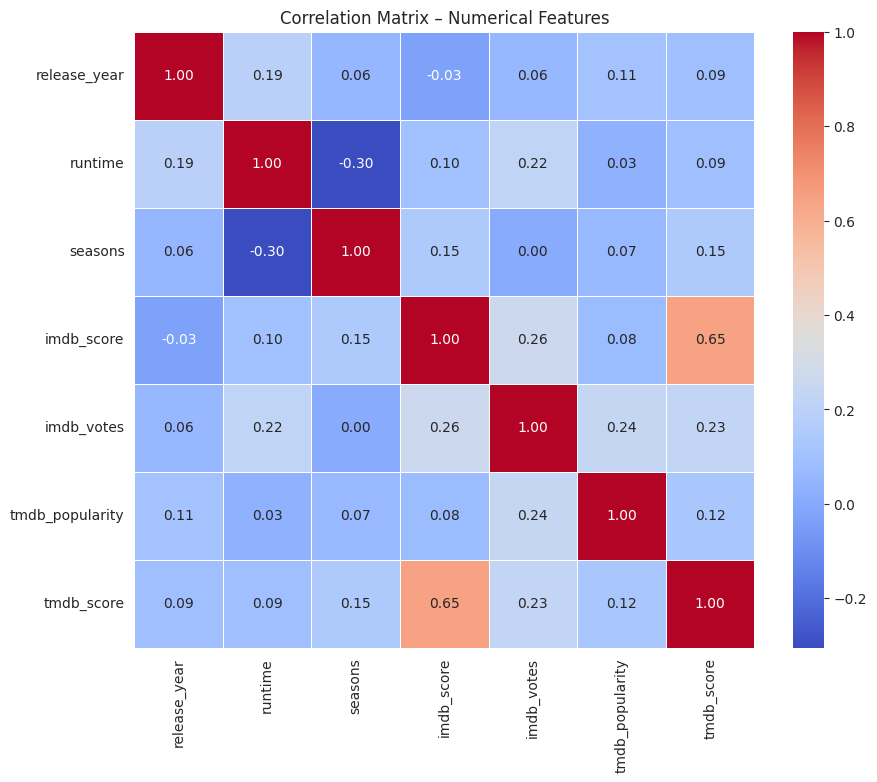

In [19]:
num_cols = ['release_year', 'runtime', 'seasons', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

plt.figure(figsize=(10,8))
sns.heatmap(
    df_analysis[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Correlation Matrix – Numerical Features")
plt.show()

# Insight: imdb_score and tmdb_score are strongly correlated.
# Weak negative correlation between release_year and imdb_score (newer content slightly lower rated on average).

## 5. Key Insights & Conclusions

1. **Content Diversity**  
   Drama, Comedy, Action, Thriller, and Documentary are the most common genres → platform caters to broad entertainment preferences.

2. **Regional Availability**  
   United States dominates production countries, followed by India and UK → strong Hollywood + growing Bollywood presence.

3. **Trends Over Time**  
   Exponential growth in titles after 2010–2015. Recent years show increasing proportion of TV Shows → strategic shift toward bingeable content.

4. **IMDb Ratings & Popularity**  
   TV Shows generally receive higher average ratings. Older titles (pre-2000) often have higher scores, possibly survivor bias.

**Business Recommendations**  
- Invest more in underrepresented genres (Sci-Fi, Animation) and regions (Latin America, Southeast Asia) to increase diversity and global appeal.  
- Prioritize TV series renewals for high-rated shows to improve retention.  
- Use rating trends to guide acquisition strategy – focus on content likely to achieve ≥7.5 IMDb.

**Final Summary**  
Amazon Prime has rapidly expanded its library since the mid-2010s, with a clear focus on movies and adult-oriented content. While quantity has grown significantly, maintaining perceived quality (ratings) will be critical for long-term subscriber growth and competitive positioning in the streaming market.